In [13]:
!pip install gurobipy


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: C:\Users\simor\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


## Step 2

### Computing and representing non-dominated solutions with 100 bricks/ 10 SRs instances

Loaded 100 bricks and 10 SRs
Raw total workload = 10.0000
Scaled total workload = 10.0000 (should be close to 10)
Office indices (0-based): [2, 17, 29, 32, 58, 65, 72, 78, 81, 97]
Distance matrix shape: (10, 100)
Disruption at minimal distance: 4.8015
Minimal achievable disruption: 0.3427
Epsilons: [0.34267542 0.7142442  1.08581297 1.45738175 1.82895052 2.2005193
 2.57208808 2.94365685 3.31522563 3.6867944  4.05836318 4.42993196
 4.80150073]
ε = 0.3427 -> dist = 27.379, disruption = 0.3427
ε = 0.7142 -> dist = 23.283, disruption = 0.7007
ε = 1.0858 -> dist = 21.396, disruption = 1.0810
ε = 1.4574 -> dist = 19.962, disruption = 1.4487
ε = 1.8290 -> dist = 18.745, disruption = 1.8028
ε = 2.2005 -> dist = 17.802, disruption = 2.1885
ε = 2.5721 -> dist = 17.069, disruption = 2.5644
ε = 2.9437 -> dist = 16.366, disruption = 2.9434
ε = 3.3152 -> dist = 15.812, disruption = 3.3139
ε = 3.6868 -> dist = 15.534, disruption = 3.6798
ε = 4.0584 -> dist = 15.276, disruption = 4.0543
ε = 4.4299 -> d

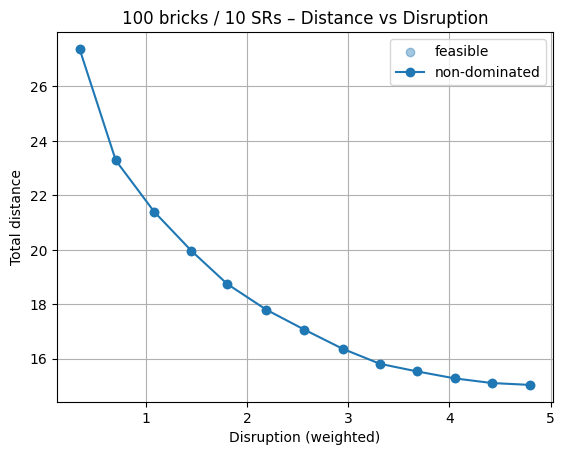

In [14]:
import pandas as pd
import numpy as np
from gurobipy import Model, GRB
import matplotlib.pyplot as plt
from pathlib import Path

CURRENT_DIR = Path.cwd()

# --- Load data: 100 bricks / 10 SRs ---
df = pd.read_excel(
    CURRENT_DIR / "data-100x10.xlsx",
    header=None,
    usecols="A:E",
    nrows=100
)
df.columns = ['x-coord', 'y-coord', 'index', 'current', 'office']

Bricks = len(df)
Sales = int(df['office'].sum())  # number of SR offices

print(f"Loaded {Bricks} bricks and {Sales} SRs")

# --- Workloads ---
workloads_raw = df['index'].astype(float).values
total_raw = workloads_raw.sum()
print(f"Raw total workload = {total_raw:.4f}")

# Normalize so that total workload = number of SRs (like the 4×22 case where sum = 4 SRs)
scale = Sales / total_raw
workloads = workloads_raw * scale
print(f"Scaled total workload = {workloads.sum():.4f} (should be close to {Sales})")

# --- Distances SR–brick ---
x_bricks = df['x-coord'].values
y_bricks = df['y-coord'].values

office_indices = df.index[df['office'] == 1].tolist()
print(f"Office indices (0-based): {office_indices}")

Distance = np.array([
    np.sqrt((x_bricks - x_bricks[o])**2 + (y_bricks - y_bricks[o])**2)
    for o in office_indices
])
print("Distance matrix shape:", Distance.shape)

# --- Initial assignment matrix (current territories) ---
SR_initial_state = np.zeros((Sales, Bricks), dtype=float)
for i in range(Bricks):
    sr = int(df.loc[i, 'current']) - 1  # current ∈ {1,…,Sales}
    if 0 <= sr < Sales:
        SR_initial_state[sr, i] = 1


def build_model():
    # Builds a fresh model with distance & disruption expressions.
    m = Model("Pfizer_100x10")
    m.Params.OutputFlag = 0  # silent

    # decision vars x[j,i] = 1 if brick i assigned to SR j
    x = m.addVars(Sales, Bricks, vtype=GRB.BINARY, name="x")

    # workload balance
    for j in range(Sales):
        m.addConstr(
            sum(x[j, i] * workloads[i] for i in range(Bricks)) <= 1.2,
            name=f"max_workload_{j}"
        )
        m.addConstr(
            sum(x[j, i] * workloads[i] for i in range(Bricks)) >= 0.8,
            name=f"min_workload_{j}"
        )

    # each brick assigned to exactly one SR
    for i in range(Bricks):
        m.addConstr(
            sum(x[j, i] for j in range(Sales)) == 1,
            name=f"assign_{i}"
        )

    # total distance
    distance_expr = sum(
        Distance[j, i] * x[j, i]
        for j in range(Sales)
        for i in range(Bricks)
    )

    # disruption (weighted by workload, same formula as Step 1)
    disruption_expr = sum(
        (SR_initial_state[j, i] - 2 * SR_initial_state[j, i] * x[j, i] + x[j, i]) / 2
        * workloads[i]
        for j in range(Sales)
        for i in range(Bricks)
    )

    return m, x, distance_expr, disruption_expr


# --- 1) Get disruption range (min disruption & disruption at min-distance) ---

# Minimize distance only
m_dist, x_dist, dist_expr_dist, disr_expr_dist = build_model()
m_dist.setObjective(dist_expr_dist, GRB.MINIMIZE)
m_dist.optimize()
if m_dist.status != GRB.OPTIMAL:
    raise RuntimeError("Distance-only model infeasible or not optimal.")
disruption_at_min_distance = disr_expr_dist.getValue()
print(f"Disruption at minimal distance: {disruption_at_min_distance:.4f}")

# Minimize disruption only
m_disr, x_disr, dist_expr_disr, disr_expr_disr = build_model()
m_disr.setObjective(disr_expr_disr, GRB.MINIMIZE)
m_disr.optimize()
if m_disr.status != GRB.OPTIMAL:
    raise RuntimeError("Disruption-only model infeasible or not optimal.")
disruption_min = disr_expr_disr.getValue()
print(f"Minimal achievable disruption: {disruption_min:.4f}")

# Build epsilon grid inside [disruption_min, disruption_at_min_distance]
if disruption_at_min_distance < disruption_min:
    # numerical corner case; swap
    disruption_min, disruption_at_min_distance = disruption_at_min_distance, disruption_min

epsilons = np.linspace(disruption_min, disruption_at_min_distance, 13)
print("Epsilons:", epsilons)

# --- 2) Epsilon-constraint loop (distance as main objective) ---

pareto_points = []  # (disruption, distance)

for eps in epsilons:
    m, x, dist_expr, disr_expr = build_model()
    # primary objective: distance (+ tiny tie-breaker on disruption, as in the text)
    m.setObjective(dist_expr + 1e-4 * disr_expr, GRB.MINIMIZE)

    # epsilon constraint on disruption
    m.addConstr(disr_expr <= float(eps) + 1e-6, name="eps_disruption")
    m.optimize()

    if m.status == GRB.OPTIMAL:
        dval = dist_expr.getValue()
        rval = disr_expr.getValue()
        pareto_points.append((rval, dval))
        print(f"ε = {eps:.4f} -> dist = {dval:.3f}, disruption = {rval:.4f}")
    else:
        print(f"ε = {eps:.4f} -> no feasible solution")

# --- 3) Extract non-dominated points ---

def non_dominated(points, tol=1e-6):
    pts = sorted(points, key=lambda p: (p[0], p[1]))  # sort by disruption, then distance
    nd = []
    best_dist = float("inf")
    for disr, dist in pts:
        if dist < best_dist - tol:
            nd.append((disr, dist))
            best_dist = dist
    return nd

if pareto_points:
    all_d, all_c = zip(*pareto_points)
    nd_pts = non_dominated(pareto_points)
    nd_d, nd_c = zip(*nd_pts)

    plt.figure()
    plt.scatter(all_d, all_c, alpha=0.4, label="feasible")
    plt.plot(nd_d, nd_c, "o-", label="non-dominated")
    plt.xlabel("Disruption (weighted)")
    plt.ylabel("Total distance")
    plt.title("100 bricks / 10 SRs – Distance vs Disruption")
    plt.grid(True)
    plt.legend()
    plt.show()
else:
    print("No Pareto points found at all.")


### Allowing assigning partial bricks

Loaded 100 bricks and 10 SR offices
Office indices (0-indexed): [2, 17, 29, 32, 58, 65, 72, 78, 81, 97]
Distance matrix shape: (10, 100)
ε = 0.4  →  minimal distance = 25.346
ε = 0.5  →  minimal distance = 24.359
ε = 0.6  →  minimal distance = 23.662
ε = 0.7  →  minimal distance = 23.114
ε = 0.8  →  minimal distance = 22.626
ε = 0.9  →  minimal distance = 22.157
ε = 1.0  →  minimal distance = 21.694
ε = 1.1  →  minimal distance = 21.258
ε = 1.2  →  minimal distance = 20.846
ε = 1.3  →  minimal distance = 20.448


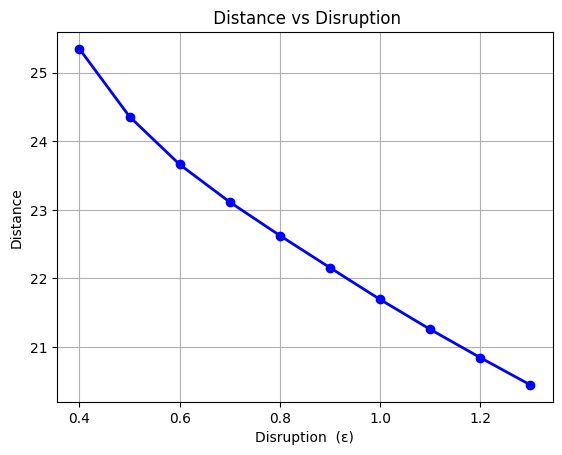

In [15]:
import pandas as pd
import numpy as np
from gurobipy import Model, GRB
import matplotlib.pyplot as plt
from pathlib import Path

CURRENT_DIR = Path.cwd()
# Read data from Excel file - first 100 rows, columns B through F
df = pd.read_excel(CURRENT_DIR/"data-100x10.xlsx", 
                   header=None, 
                   usecols="A:E",
                   nrows=100)

# Assign column names manually
df.columns = ['x-coord', 'y-coord', 'index', 'current', 'office']

# Extract parameters
Bricks = len(df)
Sales = int(df['office'].sum())  # Count number of offices (1s in office column)

print(f"Loaded {Bricks} bricks and {Sales} SR offices")

model = Model("Bricks_and_Sales_Reps_100")

### Read data from Excel
# Workloads from 'index' column
workloads = df['index'].values

# Get SR office indices (where office == 1)
office_indices = df[df['office'] == 1].index.tolist()

print(f"Office indices (0-indexed): {office_indices}")

# Extract coordinates
x_Brics = df['x-coord'].values
Y_Brics = df['y-coord'].values

# Implementation of Distance Matrix with center for each SR
# Distance from each SR office to all bricks
Distance = np.array([
    np.sqrt((x_Brics[:] - x_Brics[office_idx])**2 + 
            (Y_Brics[:] - Y_Brics[office_idx])**2) 
    for office_idx in office_indices
])

print(f"Distance matrix shape: {Distance.shape}")

# Create initial state from 'current' column
SR_initial_state = np.zeros((Sales, Bricks), dtype=float)

for i in range(Bricks):
    sr_assignment = int(df.loc[i, 'current']) - 1  # Convert to 0-indexed
    if 0 <= sr_assignment < Sales:
        SR_initial_state[sr_assignment, i] = 1

#Variables
SR_10 = model.addVars(Sales, Bricks, vtype=GRB.CONTINUOUS, name="SR_10")

## Constraints Workloads
for j in range(Sales):
    model.addConstr(
        sum(SR_10[j,i] * workloads[i] for i in range(Bricks)) <= 1.2,
        name=f"max_workload_10SR_{j}"
    )
    model.addConstr(
        sum(SR_10[j,i] * workloads[i] for i in range(Bricks)) >= 0.8,
        name=f"min_workload_10SR_{j}"
    )
    
## Constraints Bricks
for i in range(Bricks):
    model.addConstr(sum(SR_10[j,i] for j in range(Sales)) == 1, name=f"brick_{i+1}_assignment")


# --- Objective 1 : total distance ---
distance_expr = (sum(
    Distance[j][i] * SR_10[j,i] 
    for i in range(Bricks)
    for j in range(Sales) 
))


# --- Objective 2 : disruption ---
disruption_expr = sum(
    (SR_initial_state[j,i] - 2 * SR_initial_state[j,i] * SR_10[j,i] + SR_10[j,i])/2 * workloads[i]
    for i in range(Bricks) for j in range(Sales)
)



# --- Epsilon-constraint loop ---
epsilons = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3]
pareto_points = []

for eps in epsilons:
    constr = model.addConstr(disruption_expr <= eps, name=f"eps_{eps}")
    
    model.setObjective(distance_expr, GRB.MINIMIZE)
    
    model.Params.OutputFlag = 0
    model.optimize()
    
    if model.status == GRB.OPTIMAL:
        pareto_points.append((eps, model.objVal))
        print(f"ε = {eps:>2}  →  minimal distance = {model.objVal:.3f}")
        
    #Delete old constraints
    model.remove(constr)
    model.update()

if pareto_points:
    eps_vals, costs = zip(*pareto_points)
    plt.plot(eps_vals, costs, 'o-', color='blue', linewidth=2)
    plt.xlabel("Disruption  (ε)")
    plt.ylabel("Distance")
    plt.title(" Distance vs Disruption")
    plt.grid(True)
    plt.show()

In [16]:
# After the epsilon loop, optimize one more time to get a final solution
model.optimize()

if model.status == GRB.OPTIMAL:
    print("\n" + "="*50)
    print("FINAL SOLUTION")
    print("="*50)
    
    # Iterate through each of the 10 Sales Representatives
    for j in range(Sales):
        print(f"\nSR_{j+1}:")
        
        # Calculate total workload for this SR
        total_load = sum(SR_10[j,i].X * workloads[i] for i in range(Bricks))
        
        # Print all assignments (including fractional ones for continuous variables)
        print(f"  Brick assignments:")
        assigned_count = 0
        for i in range(Bricks):
            if SR_10[j,i].X > 0.001:  # Only show non-zero assignments
                print(f"    Brick {i+1}: {SR_10[j,i].X:.4f}")
                assigned_count += 1
        
        print(f"  Total bricks assigned (>0.001): {assigned_count}")
        print(f"  Total workload: {total_load:.4f}")
    
    # Print overall statistics
    print("\n" + "="*50)
    print("OVERALL STATISTICS")
    print("="*50)
    print(f"Total distance: {model.objVal:.3f}")
    print(f"Total disruption: {disruption_expr.getValue():.4f}")


FINAL SOLUTION

SR_1:
  Brick assignments:
    Brick 1: 1.0000
    Brick 2: 1.0000
    Brick 3: 1.0000
    Brick 4: 1.0000
    Brick 5: 1.0000
    Brick 11: 1.0000
    Brick 12: 1.0000
    Brick 13: 1.0000
    Brick 14: 1.0000
    Brick 15: 1.0000
    Brick 21: 1.0000
    Brick 24: 0.6211
  Total bricks assigned (>0.001): 12
  Total workload: 1.2000

SR_2:
  Brick assignments:
    Brick 6: 1.0000
    Brick 7: 1.0000
    Brick 8: 1.0000
    Brick 9: 1.0000
    Brick 16: 1.0000
    Brick 17: 1.0000
    Brick 18: 1.0000
    Brick 26: 1.0000
    Brick 27: 1.0000
    Brick 28: 1.0000
    Brick 36: 1.0000
    Brick 37: 0.0995
    Brick 38: 0.0739
  Total bricks assigned (>0.001): 13
  Total workload: 1.2000

SR_3:
  Brick assignments:
    Brick 10: 1.0000
    Brick 19: 1.0000
    Brick 20: 1.0000
    Brick 29: 1.0000
    Brick 30: 1.0000
    Brick 38: 0.9261
    Brick 39: 1.0000
    Brick 40: 1.0000
  Total bricks assigned (>0.001): 8
  Total workload: 0.8000

SR_4:
  Brick assignments:
   

### Adding an SR

Total workload (+25%): 5.0


Disruption at min distance: 10.0000
Minimal disruption: 2.0000
Epsilons: [ 2.          2.66666667  3.33333333  4.          4.66666667  5.33333333
  6.          6.66666667  7.33333333  8.          8.66666667  9.33333333
 10.        ]
ε = 2.0000 -> dist = 180.910, disruption = 2.0000
ε = 2.6667 -> dist = 180.910, disruption = 2.0000
ε = 3.3333 -> dist = 165.920, disruption = 3.0000
ε = 4.0000 -> dist = 151.650, disruption = 4.0000
ε = 4.6667 -> dist = 151.650, disruption = 4.0000
ε = 5.3333 -> dist = 150.870, disruption = 5.0000
ε = 6.0000 -> dist = 149.800, disruption = 6.0000
ε = 6.6667 -> dist = 149.800, disruption = 6.0000
ε = 7.3333 -> dist = 148.320, disruption = 7.0000
ε = 8.0000 -> dist = 148.320, disruption = 7.0000
ε = 8.6667 -> dist = 148.320, disruption = 7.0000
ε = 9.3333 -> dist = 148.320, disruption = 7.0000
ε = 10.0000 -> dist = 148.320, disruption = 7.0000


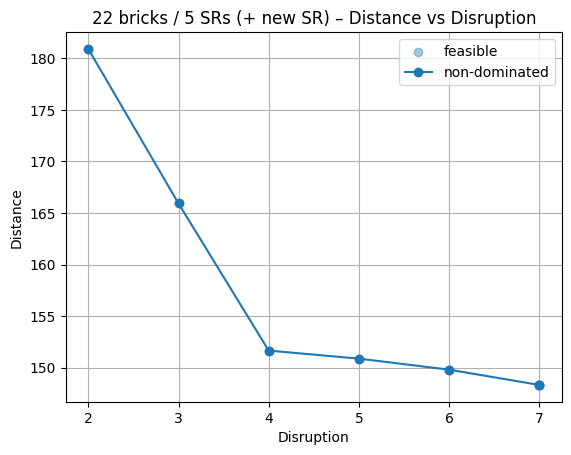

In [17]:
# --- Imports ---
import numpy as np
import matplotlib.pyplot as plt
from gurobipy import Model, GRB, quicksum

# --- Data / parameters ---
num_bricks = 22

# Distances from each brick (row) to each of the 4 existing SR offices (columns)
distances = [
    [16.16, 24.08, 24.32, 21.12], 
    [19,    26.47, 27.24, 17.33], 
    [25.29, 32.49, 33.42, 12.25], 
    [0,     7.93,  8.31,  36.12], 
    [3.07,  6.44,  7.56,  37.37], 
    [1.22,  7.51,  8.19,  36.29], 
    [2.80,  10.31, 10.95, 33.50], 
    [2.87,  5.07,  5.67,  38.80], 
    [3.80,  8.01,  7.41,  38.16], 
    [12.35, 4.52,  4.35,  48.27], 
    [11.11, 3.48,  2.97,  47.14], 
    [21.99, 22.02, 24.07, 39.86], 
    [8.82,  3.30,  5.36,  43.31], 
    [7.93,  0.00,  2.07,  43.75], 
    [9.34,  2.25,  1.11,  45.43], 
    [8.31,  2.07,  0.00,  44.43], 
    [7.31,  2.44,  1.11,  43.43], 
    [7.55,  0.75,  1.53,  43.52], 
    [11.13, 18.41, 19.26, 25.40], 
    [17.49, 23.44, 24.76, 23.21], 
    [11.03, 18.93, 19.28, 25.43], 
    [36.12, 43.75, 44.43,  0.00]
]

D = np.array(distances)
assert D.shape == (num_bricks, 4)

# Workloads (+25% demand)
workloads = [
    0.1609, 0.1164, 0.1026, 0.1516, 0.0939, 
    0.1320, 0.0687, 0.0930, 0.2116, 0.2529, 
    0.0868, 0.0828, 0.0975, 0.8177, 0.4115, 
    0.3795, 0.0710, 0.0427, 0.1043, 0.0997, 
    0.1698, 0.2531
]
workloads = [w * 1.25 for w in workloads]  # uniform +25%

print("Total workload (+25%):", sum(workloads))

# Initial states (4 SRs, before adding the 5th)
SR1_initial_state = [0,0,0,1,1,1,1,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0]
SR2_initial_state = [0,0,0,0,0,0,0,0,0,1,1,1,1,1,0,0,0,0,0,0,0,0]
SR3_initial_state = [0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,1,1,0,0,0,0]
SR4_initial_state = [1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1]
SR5_initial_state = [0]*num_bricks  # new SR has no current bricks

Sales = 5  # 4 existing + 1 new


def build_model():
    m = Model("OptionB_5SR")
    m.Params.OutputFlag = 0  # silent

    # Assignment vars for each SR
    SR_1 = m.addVars(num_bricks, vtype=GRB.BINARY, name="SR_1")
    SR_2 = m.addVars(num_bricks, vtype=GRB.BINARY, name="SR_2")
    SR_3 = m.addVars(num_bricks, vtype=GRB.BINARY, name="SR_3")
    SR_4 = m.addVars(num_bricks, vtype=GRB.BINARY, name="SR_4")
    SR_5 = m.addVars(num_bricks, vtype=GRB.BINARY, name="SR_5")

    # Choose where the new SR office is located.
    # Here we simplify: SR5's office must coincide with one of the 4 existing SR offices
    choose_cols = range(4)  # column j corresponds to office j in D
    z = m.addVars(choose_cols, vtype=GRB.BINARY, name="choose_col")
    m.addConstr(quicksum(z[j] for j in choose_cols) == 1, name="one_column")

    # y[i,j] = 1 if brick i is assigned to SR5 AND SR5's office is column j
    y = m.addVars(range(num_bricks), choose_cols, vtype=GRB.BINARY, name="y")
    for i in range(num_bricks):
        for j in choose_cols:
            m.addConstr(y[i, j] <= SR_5[i])
            m.addConstr(y[i, j] <= z[j])
            m.addConstr(y[i, j] >= SR_5[i] + z[j] - 1)

    # Workload balance for each SR
    for SR, name in [(SR_1, "SR1"), (SR_2, "SR2"), (SR_3, "SR3"), (SR_4, "SR4"), (SR_5, "SR5")]:
        m.addConstr(quicksum(SR[i] * workloads[i] for i in range(num_bricks)) <= 1.2,
                    name=f"max_workload_{name}")
        m.addConstr(quicksum(SR[i] * workloads[i] for i in range(num_bricks)) >= 0.8,
                    name=f"min_workload_{name}")

    # Each brick assigned exactly once
    for i in range(num_bricks):
        m.addConstr(
            SR_1[i] + SR_2[i] + SR_3[i] + SR_4[i] + SR_5[i] == 1,
            name=f"assign_{i}"
        )

    # Distance objective
    distance_expr = quicksum(
        D[i, 0] * SR_1[i] +
        D[i, 1] * SR_2[i] +
        D[i, 2] * SR_3[i] +
        D[i, 3] * SR_4[i]
        for i in range(num_bricks)
    )
    distance_expr += quicksum(
        D[i, j] * y[i, j]
        for i in range(num_bricks)
        for j in choose_cols
    )

    # Disruption objective (same formula as step 1, extended to SR5)
    disruption_expr = quicksum(
        (SR1_initial_state[i] - 2 * SR1_initial_state[i] * SR_1[i] + SR_1[i] +
         SR2_initial_state[i] - 2 * SR2_initial_state[i] * SR_2[i] + SR_2[i] +
         SR3_initial_state[i] - 2 * SR3_initial_state[i] * SR_3[i] + SR_3[i] +
         SR4_initial_state[i] - 2 * SR4_initial_state[i] * SR_4[i] + SR_4[i] +
         SR5_initial_state[i] - 2 * SR5_initial_state[i] * SR_5[i] + SR_5[i]) / 2
        for i in range(num_bricks)
    )

    return m, (SR_1, SR_2, SR_3, SR_4, SR_5), distance_expr, disruption_expr


# --- 1) Get disruption range ---

# distance-only
m_dist, SRs_dist, dist_expr_dist, disr_expr_dist = build_model()
m_dist.setObjective(dist_expr_dist, GRB.MINIMIZE)
m_dist.optimize()
if m_dist.status != GRB.OPTIMAL:
    raise RuntimeError("Distance-only model infeasible.")
disr_at_min_dist = disr_expr_dist.getValue()
print(f"Disruption at min distance: {disr_at_min_dist:.4f}")

# disruption-only
m_disr, SRs_disr, dist_expr_disr, disr_expr_disr = build_model()
m_disr.setObjective(disr_expr_disr, GRB.MINIMIZE)
m_disr.optimize()
if m_disr.status != GRB.OPTIMAL:
    raise RuntimeError("Disruption-only model infeasible.")
disr_min = disr_expr_disr.getValue()
print(f"Minimal disruption: {disr_min:.4f}")

if disr_at_min_dist < disr_min:
    disr_min, disr_at_min_dist = disr_at_min_dist, disr_min

epsilons = np.linspace(disr_min, disr_at_min_dist, 13)
print("Epsilons:", epsilons)

# --- 2) Epsilon-constraint loop ---

pareto_points = []

for eps in epsilons:
    m, SRs, dist_expr, disr_expr = build_model()
    m.setObjective(dist_expr + 1e-4 * disr_expr, GRB.MINIMIZE)
    m.addConstr(disr_expr <= float(eps) + 1e-6, name="eps_disr")
    m.optimize()

    if m.status == GRB.OPTIMAL:
        dval = dist_expr.getValue()
        rval = disr_expr.getValue()
        pareto_points.append((rval, dval))
        print(f"ε = {eps:.4f} -> dist = {dval:.3f}, disruption = {rval:.4f}")
    else:
        print(f"ε = {eps:.4f} -> no feasible solution")

# --- 3) Non-dominated set & plot ---

def non_dominated(points, tol=1e-6):
    pts = sorted(points, key=lambda p: (p[0], p[1]))
    nd = []
    best_d = float("inf")
    for disr, dist in pts:
        if dist < best_d - tol:
            nd.append((disr, dist))
            best_d = dist
    return nd

if pareto_points:
    all_d, all_c = zip(*pareto_points)
    nd_pts = non_dominated(pareto_points)
    nd_d, nd_c = zip(*nd_pts)

    plt.figure()
    plt.scatter(all_d, all_c, alpha=0.4, label="feasible")
    plt.plot(nd_d, nd_c, "o-", label="non-dominated")
    plt.xlabel("Disruption")
    plt.ylabel("Distance")
    plt.title("22 bricks / 5 SRs (+ new SR) – Distance vs Disruption")
    plt.grid(True)
    plt.legend()
    plt.show()
else:
    print("No Pareto points found.")
